----
# Laboratorium 10 - Filtry analogowe, część 1

----
Materiały dydaktyczne przeznaczone są wyłącznie dla studentów wydziału Informatyki i Telekomunikacji Politechniki Poznańskie

----
## 0. Zagadnienia do opanowania przed zajęciami
----
### 0.1. Obsługa języka Python oraz bibliotek `numpy`, `matplotlib`, `imageio` oraz `scipy.signal`.
### 0.2. Przypomnienie wiadomości o filtrach analogowych
### 0.3. Moduł transmitancji i tłumienie
### 0.4.  Gabaryty filtru
### 0.5.  Aproksymacje Butterwortha, Czebyszewa (1 i 2 rodzaju) i Cauera (eliptyczna)


In [1]:
%matplotlib inline
import sympy 
import scipy.signal 
import numpy as np
import matplotlib.pyplot as plt 



----

### Zadanie 1

Zaprojektować 5 dolnoprzepustowych filtrów (analogowych):
    - aproksymacji Butterwortha   
    - rząd filtru n (dla n od 1 do 5)  
    - pulsacja graniczna ω=1 rad/s  
    - wykreślić charakterystyki amplitudowe (na jednym wykresie) oraz tłumienia (na jednym, innym wykresie)
    - odczytać z wykresu nachylenie charakterystyki amplitudowej w paśmie zaporowym  (dB/oct)

Podpowiedz:  
    - wykorzystaj funkcję `scipy.signal.butter`, pamiętaj aby zaprojektować filtr analogowy  
    - do wyznaczenia próbek transmitancji uzyj funkcji `scipy.signal.freqs`

-5.811291239716322
-11.734530392228578
-17.627820944064823
-23.515308764778922
-29.400687238260332


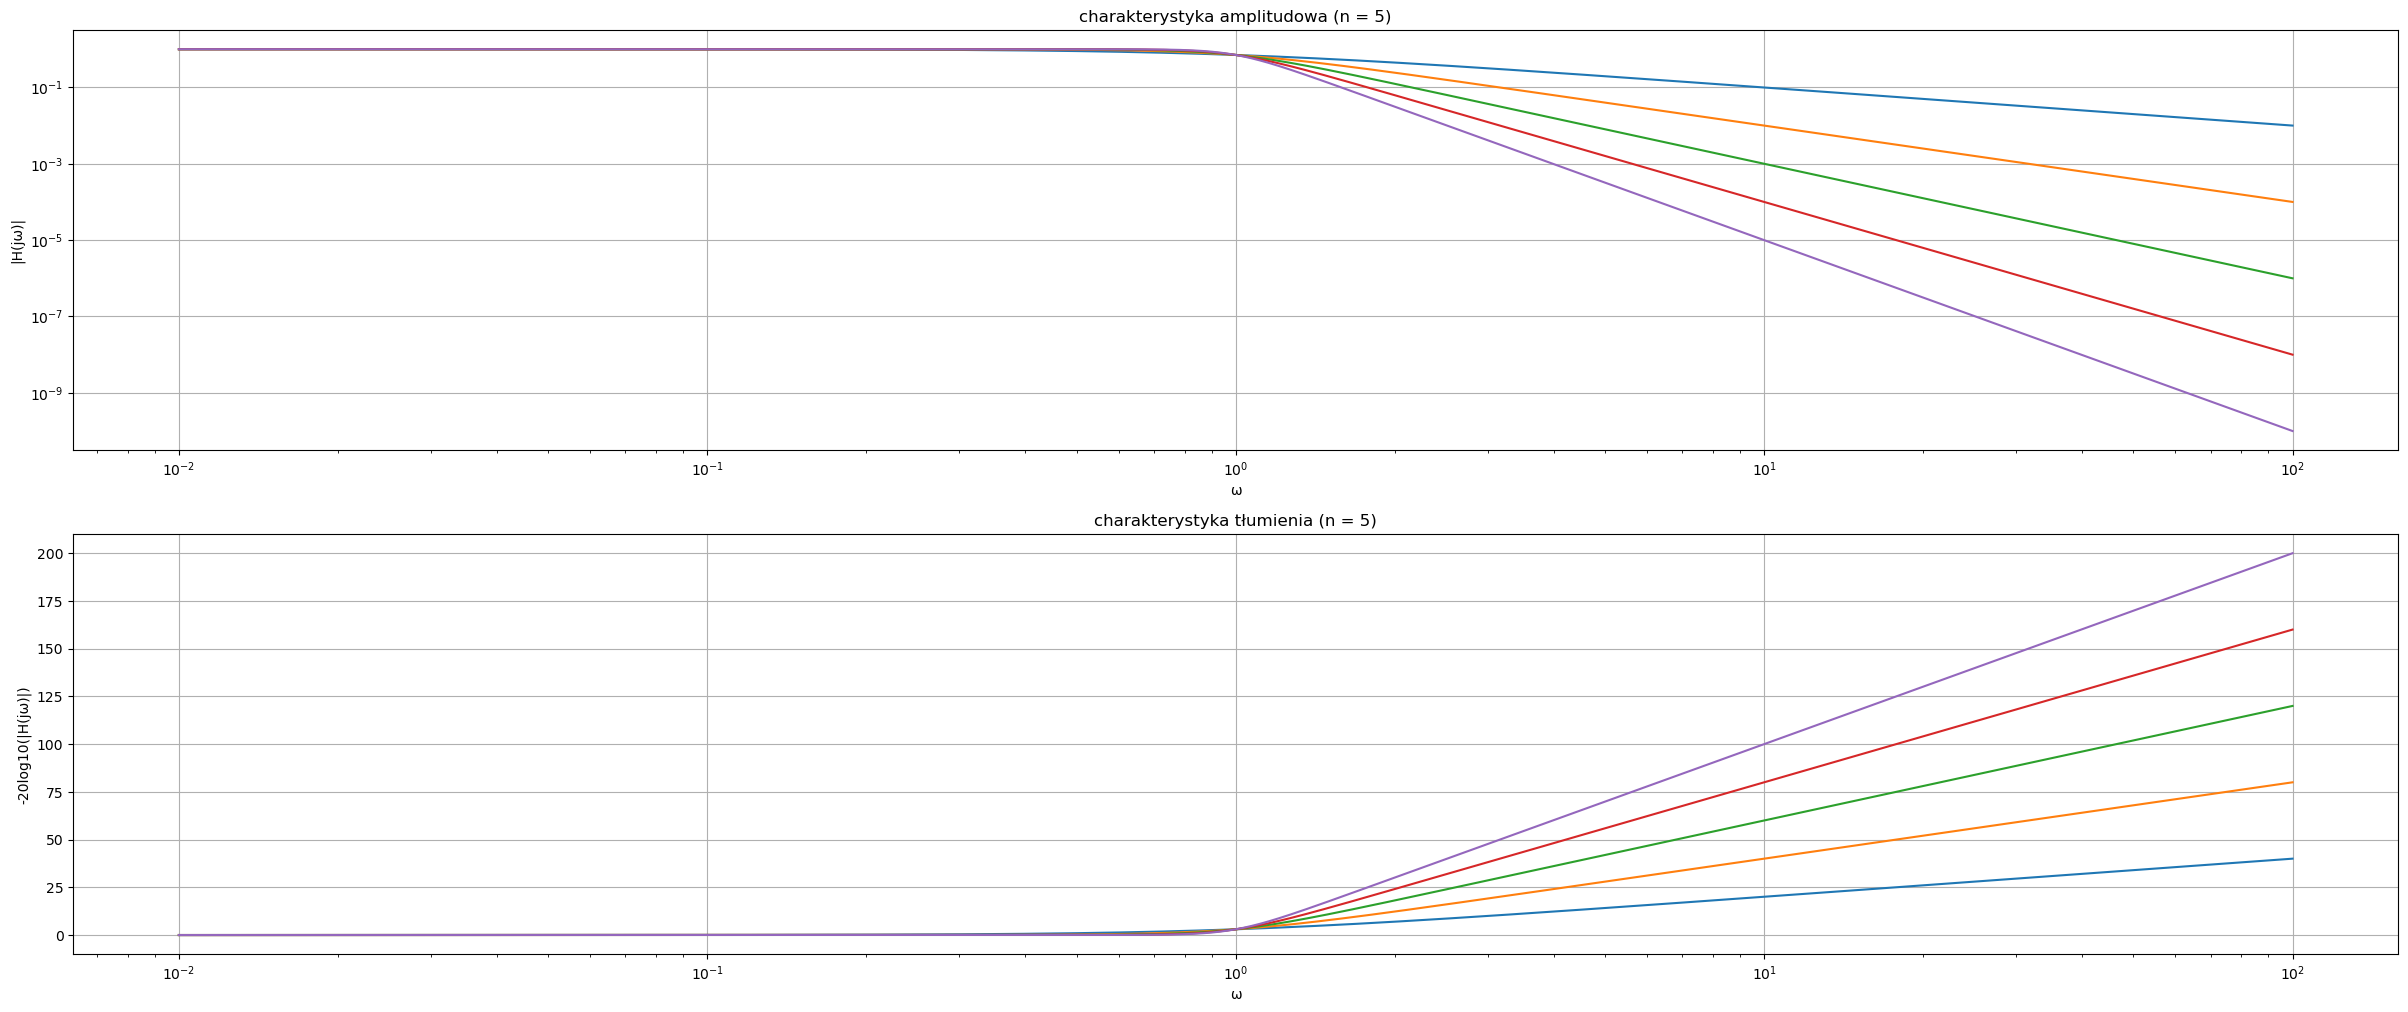

In [16]:
n  = 5
wp = 1
fig, axs = plt.subplots(2, 1, figsize=[6*n,12])    
#log w vector
w = np.logspace(-2,2,10000)

for i in range(1,n+1):    
    #design filter
    b, a = scipy.signal.butter(i,wp,btype="lowpass" ,analog=True) #btype jest defaultowo lowpass 

    #calculate transmitance samples and magnitude characteristic
    w_out, h = scipy.signal.freqs(b,a, worN=w)

    magnitude = np.abs(h)

    #calculate Attenuation 
    attenuation = -20 * np.log10(magnitude)

    #calculate attenuation per octave
    w1 = 20
    w2 = 2*w1
    B = np.poly1d(b)
    A = np.poly1d(a)
    A1 = 20*np.log10(np.abs(B(w1)/A(w1)))
    A2 = 20*np.log10(np.abs((B(w2)/A(w2))))
    da = A2 - A1
    print (da)


    #display magnitude characteristic
    axs[0].loglog(w_out, magnitude   )
    axs[0].set_title("charakterystyka amplitudowa (n = %d)"%(i))
    axs[0].set_xlabel("ω")
    axs[0].set_ylabel("|H(jω)|")
    axs[0].grid()
    axs[1].semilogx(w_out, attenuation  )
    axs[1].set_title("charakterystyka tłumienia (n = %d)"%(i))
    axs[1].set_xlabel("ω")
    axs[1].set_ylabel("-20log10(|H(jω)|)")
    axs[1].grid()

### Zadanie 2

Zaprojektować 5 dolnoprzepustowych filtrów (analogowych):
    - aproksymacji Czebyszewa I rodzaju   
    - rząd filtru n (dla n od 1 do 5)  
    - maksymalne tłumienie w pasmie przepustowym 1 dB (rp, ripple).  
    - pulsacja graniczna ω=1 rad/s  
    - wykreślić charakterystyki amplitudowe (na jednym wykresie) oraz tłumienia (na jednym, innym wykresie)  
    - odczytać z wykresu nachylenie charakterystyki amplitudowej w paśmie zaporowym  (dB/oct)

Podpowiedź:  
    - wykorzystaj funkcję `scipy.signal.cheby1`, pamiętaj aby zaprojektować filtr analogowy, maksymalne tętnienie (rp, ripple) oznacza  maksymalne tłumienie w paśmie przepustowym  
    - do wyznaczenia próbek transmitancji uzyj funkcji `scipy.signal.freqs`

-5.623077667407578
-11.795399042043826
-17.835373273186562
-23.859568310529696
-29.87955434310132


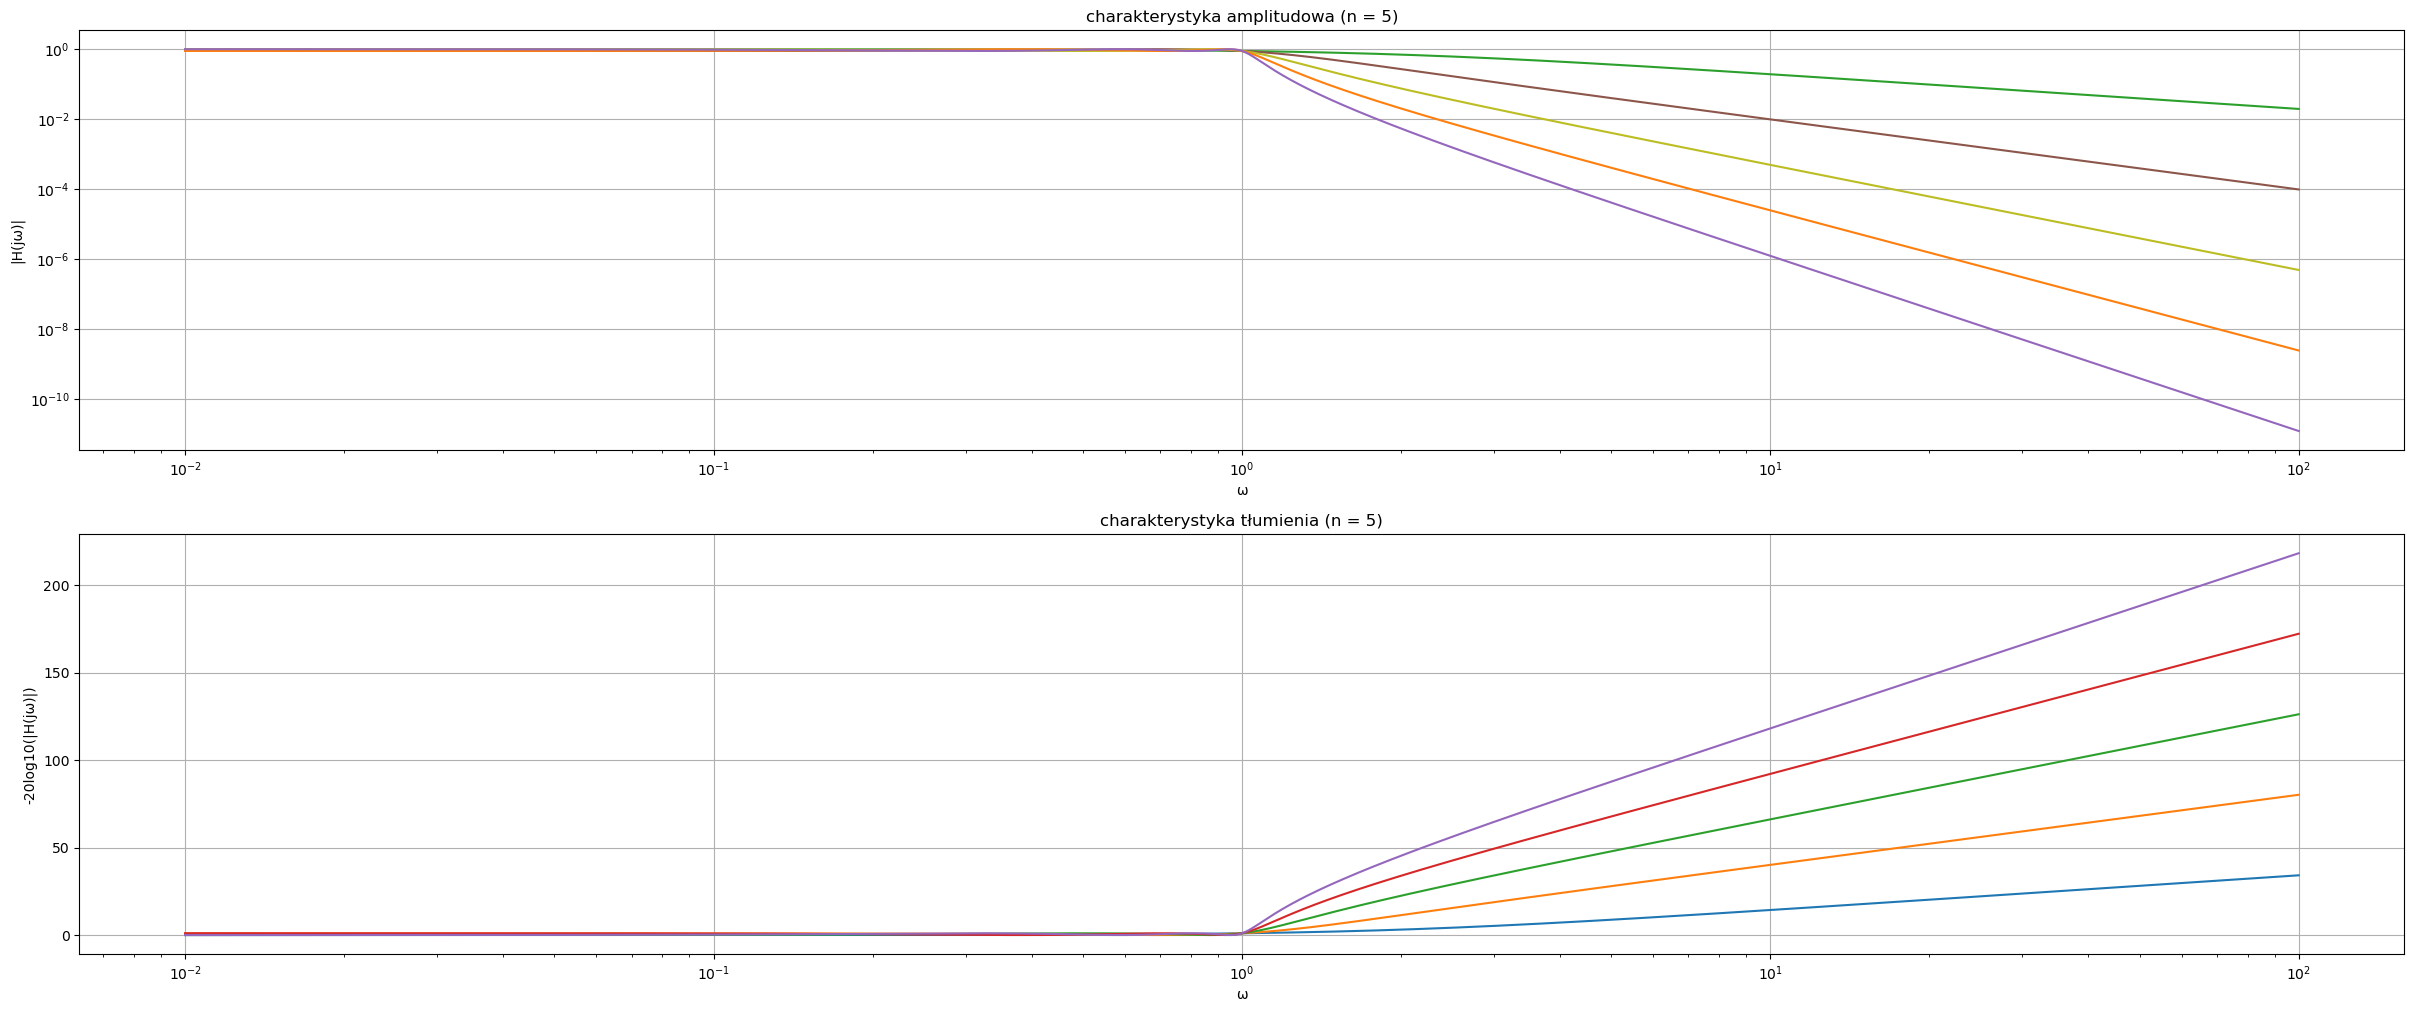

In [27]:
n  = 5
wp = 1
fig, axs = plt.subplots(2, 1, figsize=[6*n,12])    
#log w vector
w = np.logspace(-2,2,10000)

for i in range(1,n+1):    
    #design filter
    b, a = scipy.signal.cheby1(i,1, wp,btype="lowpass",analog=True)
    

    #calculate transmitance samples and magnitude characteristic
    w_out, h = scipy.signal.freqs(b,a, worN=w)

    #calculate Attenuation 
    magnitude = np.abs(h)
    attenuation = -20 * np.log10(magnitude)
    
    

    #calculate attenuation per octave
    w1 = 20
    w2 = 2*w1
    B = np.poly1d(b)
    A = np.poly1d(a)
    A1 = 20*np.log10(np.abs(B(w1)/A(w1)))
    A2 = 20*np.log10(np.abs((B(w2)/A(w2))))
    da = A2 - A1
    print (da)


    #display magnitude characteristic
    axs[0].loglog(w1,A1,'+')
    axs[0].loglog(w2,A2,'+')
    axs[0].loglog(w_out, magnitude  )
    axs[0].set_title("charakterystyka amplitudowa (n = %d)"%(i))
    axs[0].set_xlabel("ω")
    axs[0].set_ylabel("|H(jω)|")
    axs[0].grid()
    axs[1].semilogx(w_out, attenuation   )
    axs[1].set_title("charakterystyka tłumienia (n = %d)"%(i))
    axs[1].set_xlabel("ω")
    axs[1].set_ylabel("-20log10(|H(jω)|)")
    axs[1].grid()

### Zadanie 3  
Porównać charakterystyki amplitudowe i fazowe dla aproksymacji Butterwortha i Czebyszewa I rodzaju:
    - rząd filtru n = 5  
    - pulsacja graniczna ω=1 rad/s  
    - maksymalne tłumienie w pasmie przepustowym 1 dB (rp, ripple).  
    - wykreślić charakterystyki amplitudowe (na jednym wykresie)  
    - wykreślić charakterystyki fazowe (na jednym wykresie)  
    - odczytać z wykresu nachylenie charakterystyki amplitudowej w paśmie zaporowym  (dB/oct)

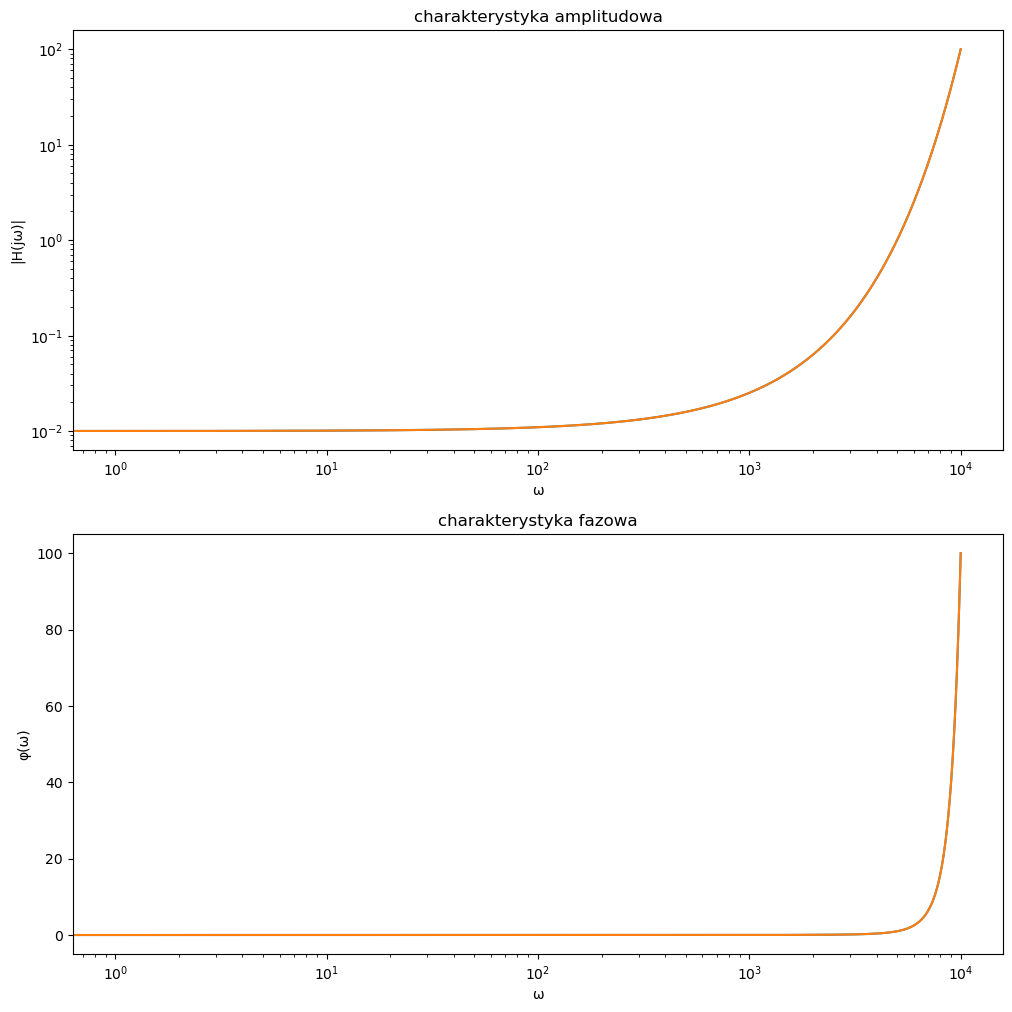

In [ ]:
n  = 5
wp = 1
fig, axs = plt.subplots(2, 1, figsize=[12,12])    
#log w vector
w = np.logspace(-2,2,10000)

#Butterworth
butterworth

#design filter

#calculate transmitance samples and magnitude characteristic

#calculate phase 

#display magnitude characteristic
axs[0].loglog(w,     )
axs[0].set_title("charakterystyka amplitudowa")
axs[0].set_xlabel("ω")
axs[0].set_ylabel("|H(jω)|")
axs[0].grid()
axs[1].semilogx(w,   )
axs[1].set_title("charakterystyka fazowa")
axs[1].set_xlabel("ω")
axs[1].set_ylabel("φ(ω)")
axs[1].grid()

#cheby
#design filter

#calculate transmitance samples and magnitude characteristic

#calculate phase 

#display magnitude characteristic
axs[0].loglog(w,    ) 
axs[0].set_title("charakterystyka amplitudowa")
axs[0].set_xlabel("ω")
axs[0].set_ylabel("|H(jω)|")
axs[0].grid()
axs[1].semilogx(w,  )
axs[1].set_title("charakterystyka fazowa")
axs[1].set_xlabel("ω")
axs[1].set_ylabel("φ(ω)")
axs[1].grid()

### Zadanie 4

Wyznaczanie minimalnego wymaganego rzędu filtru:  
 ### gabaryty: 
 - a)   αp= 3 dB, αs= 80 dB, ωp= 3 rad/s, ωs= 8 rad/s  
 - b)   αp= 0,5 dB, αs= 100 dB, ωp= 2 rad/s, ωs= 3 rad/s
### filtry:  
 - Butterwortha
 - Czebyszewa I rodzaju
 - Czebyszewa II rodzaju
 - Cauer (eliptyczny)

### Podpowiedź : 
 - użyj funkcji: `scipy.signal.buttord`, `scipy.signal.cheb1ord`, `scipy.signal.cheb2ord`, `scipy.signal.ellipord`

In [ ]:
# I - case
#αp= 3 dB, αs= 80 dB, ωp= 3 rad/s, ωs= 8 rad/s 
w_p = 3
w_s = 8
a_p = 3
a_s = 80
butterworth = scipy.signal.buttord(w_p, w_s, a_p, a_s, analog=True)
print(butterworth)
cheby = scipy.signal.cheb1ord(w_p, w_s, a_p, a_s, analog=True)
print(cheby)
cheby2 = scipy.signal.cheb2ord(w_p, w_s, a_p, a_s, analog=True)
print(cheby2)
eli = scipy.signal.ellipord(w_p, w_s, a_p, a_s, analog=True)
print(eli)


# II-nd case
# αp= 0,5 dB, αs= 100 dB, ωp= 2 rad/s, ωs= 3 rad/s
print("II-nd case")

w_p = 2
w_s = 3
a_p = 0.5
a_s = 100
butterworth = scipy.signal.buttord(w_p, w_s, a_p, a_s, analog=True)
print(butterworth)
cheby = scipy.signal.cheb1ord(w_p, w_s, a_p, a_s, analog=True)
print(cheby)
cheby2 = scipy.signal.cheb2ord(w_p, w_s, a_p, a_s, analog=True)
print(cheby2)
eli = scipy.signal.ellipord(w_p, w_s, a_p, a_s, analog=True)
print(eli)


(10, 3.000712426093548)
(7, 3.0)
(7, 6.5398336846586975)
(5, 3.0)
II-nd case
(31, 2.0690218064506554)
(14, 2.0)
(14, 2.9658458895301596)
(9, 2.0)


### Zadanie 5   

Korzystając z napisanej w zadaniu 5 funkcji powtórz zadania 1-4 dla filtru górnoprzepustowego.

### Podpowiedź 
- zmień parametr `btype` poszczególnych funkcji na "high"
- pamiętaj, aby zmienić pulsację przy wyznaczniu tłumienia na oktawę tak, aby obliczać je w obszarze zaporowym
 

### Zadanie 6 

Napisz funkcję:
 - wyliczającą rząd filtru dla danej aproksymacji 
 - projektującą filtr (transmitancja) 
 - wykreślanie charakterystyk amplitudowych filtrów wraz z liniami odpowiadającymi gabarytom filtrów 

#### Paniętaj, że dla filtru Czebyszewa II typu, funkcja projektująca transmitancję filtru przyjmuje wartość `ws` jako argument o nazwie `wn` (patrz dokumentacja)

Wyświetl filtry a) i b) z zadania 4 dla wszystkich aproksymacji (na jednym wykresie charakterystyki dla danych gabarytów)

In [6]:
def designFilter(Appr, Type, wp, ws, lp, ls):
  #find order and design filter
  if   Appr == 'Butterworth'  : 
       n, _ = 
       B,A = 
  elif Appr == 'Chebyshev1': 
      n, _ =
      B, A =  
  elif Appr == 'Chebyshev2': 
      n, _ = 
      B, A =  
  elif Appr == 'Elliptic' : 
      n, _ = 
      B, A =  
  else :  
      print("Appr not found!!!"); return None
  return (B, A, n)

def drawLimitsM(ax, Type, wp, ws, lp, ls):
  Hp=10**(-lp/20)
  Hs=10**(-ls/20) 
  if   Type == 'low' or Type == 'lowpass': 
    ax.fill([w[0], w[0],  wp   ,  wp   ], [Hs, Hp, Hp, Hs], '0.5', lw=0, alpha=0.5) # pass
    ax.fill([ws  , ws  ,  w[-1],  w[-1]], [Hp, Hs, Hs, Hp], '0.5', lw=0, alpha=0.5) # stop
  elif Type == 'high' or Type == 'highpass': 
    ax.fill([w[0], w[0],  ws   ,  ws   ], [Hp, Hs, Hs, Hp], '0.5', lw=0, alpha=0.5) # stop
    ax.fill([wp  , wp  ,  w[-1],  w[-1]], [Hs, Hp, Hp, Hs], '0.5', lw=0, alpha=0.5) # pass
  elif Type == 'bandpass': 
    ax.fill([w[0] ,  w[0],  ws[0], ws[0]], [Hp, Hs, Hs, Hp], '0.5', lw=0, alpha=0.5) # stop
    ax.fill([wp[0], wp[0],  wp[1], wp[1]], [Hs, Hp, Hp, Hs], '0.5', lw=0, alpha=0.5) # pass
    ax.fill([ws[1], ws[1],  w[-1], w[-1]], [Hp, Hs, Hs, Hp], '0.5', lw=0, alpha=0.5) # stop
  elif Type == 'bandstop':
    ax.fill([w[0] ,  w[0],  wp[0], wp[0]], [Hs, Hp, Hp, Hs], '0.5', lw=0, alpha=0.5) # pass
    ax.fill([ws[0], ws[0],  ws[1], ws[1]], [Hp, Hs, Hs, Hp], '0.5', lw=0, alpha=0.5) # stop
    ax.fill([wp[1], wp[1],  w[-1], w[-1]], [Hs, Hp, Hp, Hs], '0.5', lw=0, alpha=0.5) # pass
  else :  
    print("Type not found!!!"); return None  
  
def drawLimitsA(ax, Type, wp, ws, lp, ls):
  if   Type == 'low' or Type == 'lowpass': 
    ax.fill([w[0], w[0],  wp   ,  wp   ], [ls, lp, lp, ls], '0.5', lw=0, alpha=0.5) # pass
    ax.fill([ws  , ws  ,  w[-1],  w[-1]], [lp, ls, ls, lp], '0.5', lw=0, alpha=0.5) # stop
  elif Type == 'high' or Type == 'highpass': 
    ax.fill([w[0], w[0],  ws   ,  ws   ], [lp, ls, ls, lp], '0.5', lw=0, alpha=0.5) # stop
    ax.fill([wp  , wp  ,  w[-1],  w[-1]], [ls, lp, lp, ls], '0.5', lw=0, alpha=0.5) # pass
  elif Type == 'bandpass': 
    ax.fill([w[0] ,  w[0],  ws[0], ws[0]], [lp, ls, ls, lp], '0.5', lw=0, alpha=0.5) # stop
    ax.fill([wp[0], wp[0],  wp[1], wp[1]], [ls, lp, lp, ls], '0.5', lw=0, alpha=0.5) # pass
    ax.fill([ws[1], ws[1],  w[-1], w[-1]], [lp, ls, ls, lp], '0.5', lw=0, alpha=0.5) # stop
  elif Type == 'bandstop':
    ax.fill([w[0] ,  w[0],  wp[0], wp[0]], [ls, lp, lp, ls], '0.5', lw=0, alpha=0.5) # pass
    ax.fill([ws[0], ws[0],  ws[1], ws[1]], [lp, ls, ls, lp], '0.5', lw=0, alpha=0.5) # stop
    ax.fill([wp[1], wp[1],  w[-1], w[-1]], [ls, lp, lp, ls], '0.5', lw=0, alpha=0.5) # pass
  else :  
    print("Type not found!!!"); return None  
  
Apprs = ["Butterworth", "Chebyshev1", "Chebyshev2", "Elliptic"]
αp=3; αs=80; ωp=3; ωs=8
#αp=0.5; αs=100; ωp=2; ωs=3

w = np.logspace(-2, 2, 10000)
fig, axs = plt.subplots(2, 1, figsize=[8,8])
drawLimitsM(axs[0], "low", ωp, ωs, αp, αs)
drawLimitsA(axs[1], "low", ωp, ωs, αp, αs)

for Appr in Apprs:
    B, A, n = designFilter(Appr, "low", ωp, ωs, αp, αs)
    H =
    M =
    A = -20*np.log10(M)
    axs[0].loglog  (w, M, label=f"{Appr} (n={n})")
    axs[1].semilogx(w, A)

axs[0].grid(which='both', axis='both')
axs[0].set_title("charakterystyka amplitudowa")
axs[0].set_xlabel("ω [rad/s]")
axs[0].set_ylabel("|H(jω)|")
axs[1].grid(which='both', axis='both')
axs[1].set_title("tłumienie")
axs[1].set_xlabel("ω [rad/s]")
axs[1].set_ylabel("α [dB]")
fig.legend()
fig.tight_layout()

SyntaxError: invalid syntax (907086943.py, line 4)